# EPIC Institute of Technology
## Data Science. Homework 4

## Dear students, welcome to your data science homework assignment! Below are the tasks you need to complete. Please follow the instructions and fill in the code cells provided. Feel free do add more cells if needed.

## Task 1: Exploratory Data Analysis (EDA)

### 1.1 Target Distribution Analysis
- Load the dataset.
- Analyze the distribution of the target variable.

       textID                                               text sentiment
0  cb774db0d1                I`d have responded, if I were going   neutral
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!  negative
2  088c60f138                          my boss is bullying me...  negative
3  9642c003ef                     what interview! leave me alone  negative
4  358bd9e861   Sons of ****, why couldn`t they put them on t...  negative
5  28b57f3990  http://www.dothebouncy.com/smf - some shameles...   neutral
6  6e0c6d75b1  2am feedings for the baby are fun when he is a...  positive
7  50e14c0bb8                                         Soooo high   neutral
8  e050245fbd                                        Both of you   neutral
9  fc2cbefa9d   Journey!? Wow... u just became cooler.  hehe....  positive

['neutral' 'negative' 'positive']
neutral     11118
positive     8582
negative     7781
Name: sentiment, dtype: int64


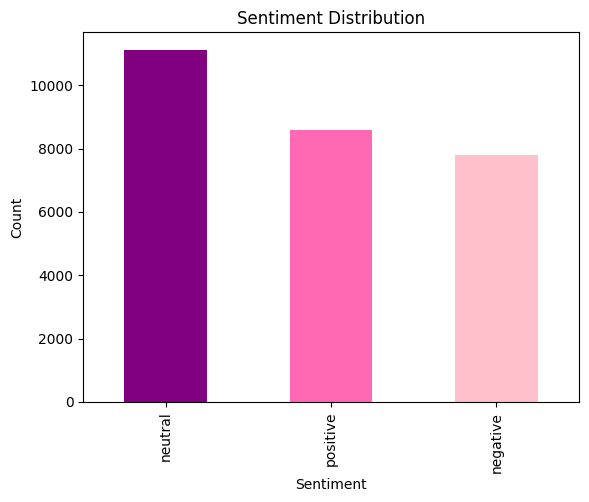

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('train.csv')
print(df[:10])
print()

unique_values_sent = df['sentiment'].unique()
print(unique_values_sent)


# Видим, что в столбце sentiment могут быть лишь 3 различных значения
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)


# Построим график для наглядного анализа
sentiment_counts.plot(kind='bar', color=['purple', 'hotpink', 'pink'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()





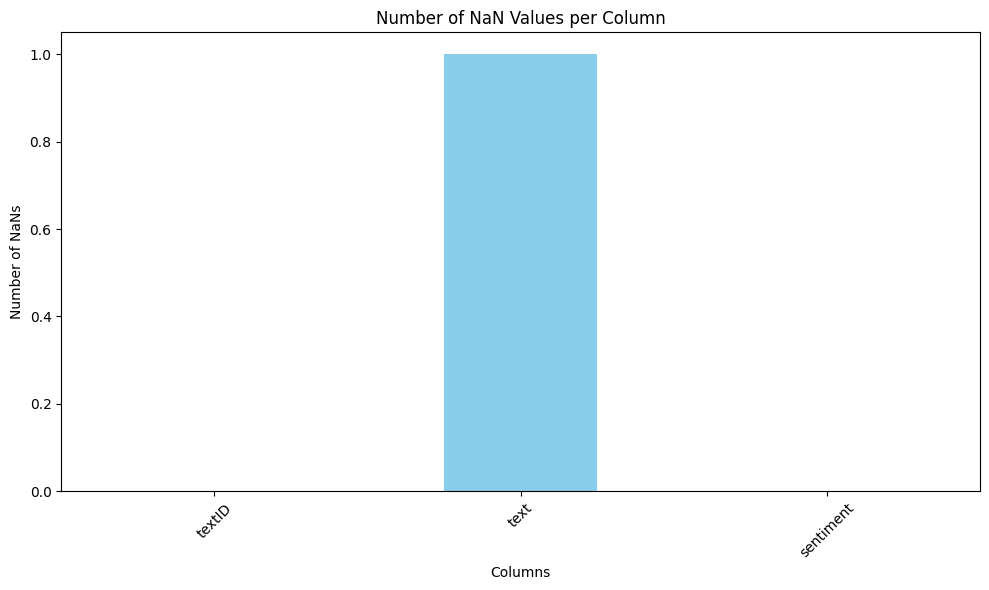

(27481, 3)


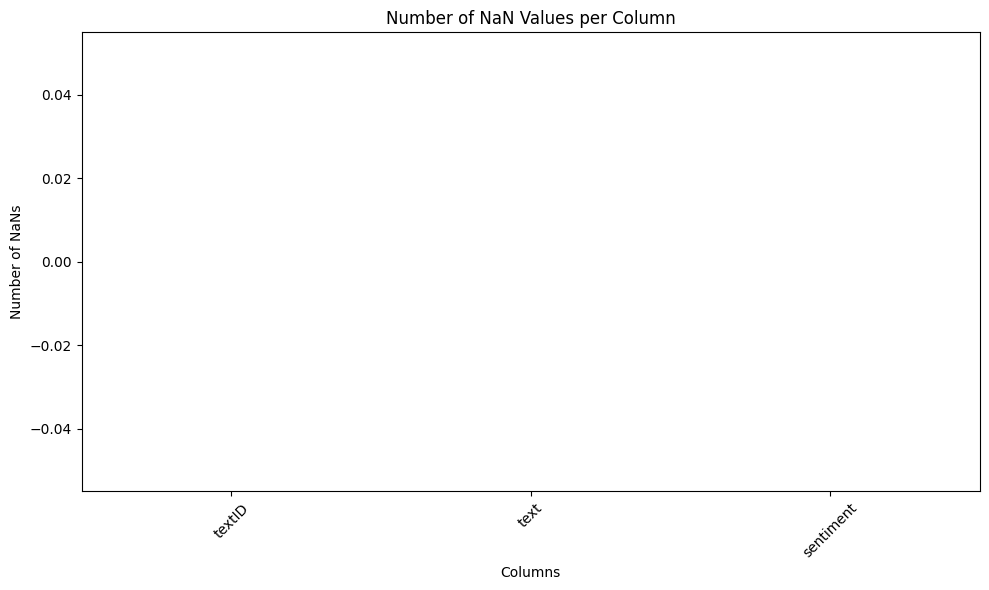

In [ ]:
# Построим диаграмму, чтобы проверить есть NaN значения в датасете
nan_counts = df.isnull().sum()


plt.figure(figsize=(10, 6))
nan_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of NaNs')
plt.title('Number of NaN Values per Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Проанализировав диаграмму, видим, что есть 1 Nan значение в столбце text
print(df.shape)
# Всего в датасете 27481 строк, поэтому, если удалить 1 строку со значением Nan
# ничего не изменится, и нет необходимости заполнять эту строку значением в sentiment
df.dropna(subset=['text'], inplace=True)
nan_counts = df.isnull().sum()


plt.figure(figsize=(10, 6))
nan_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Number of NaNs')
plt.title('Number of NaN Values per Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Удалив Nan значение проанализируем график на наличие Nan значений: их нет



### 1.2 Wordclouds for Each Target
- Create wordclouds for each target.

In [ ]:
from wordcloud import WordCloud


# Создание текстов для каждой категории 'sentiment'
# Очищать тексты от стоп-слов и знаков препиния нет смысла при создании wordcloud, т.к. это автоматически будет выполнено
text_sentiment_neutral = df[df['sentiment'] == 'neutral']['text']
sentences_n = text_sentiment_neutral.tolist()
text_n=" ".join(sentences_n)



text_sentiment_negative = df[df['sentiment'] == 'negative']['text']
sentences_neg = text_sentiment_negative.tolist()
text_neg=" ".join(sentences_neg)

text_sentiment_positive = df[df['sentiment'] == 'positive']['text']
sentences_p = text_sentiment_positive.tolist()
text_p=" ".join(sentences_p)


# чтобы в дальнейшем не было необходимости создавать различные стоп-слова, но в разных регистрах;
# это увеличит скорость выполнения
text_n=text_n.lower()
text_neg=text_neg.lower()
text_p=text_p.lower()



print(len(text_n),len(text_neg),len(text_p))

736020 556248 612918


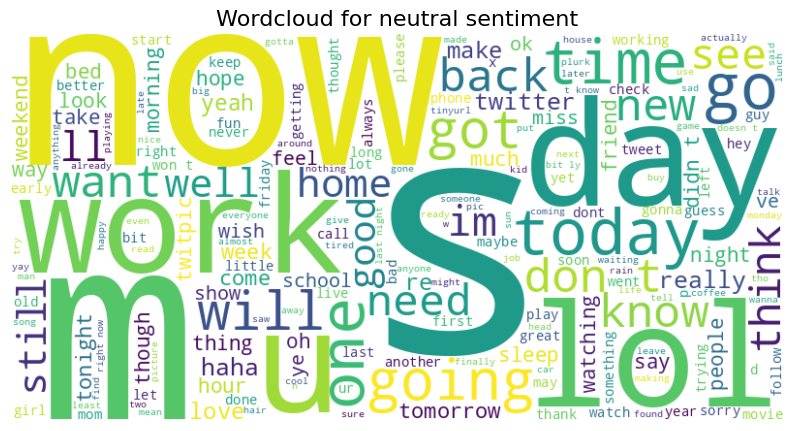

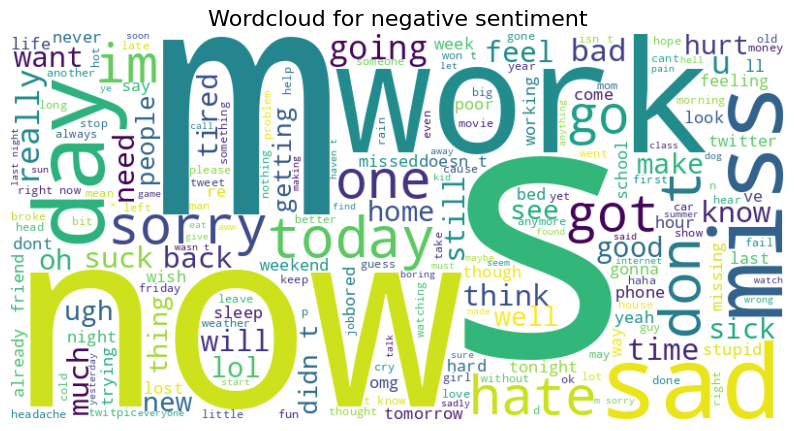

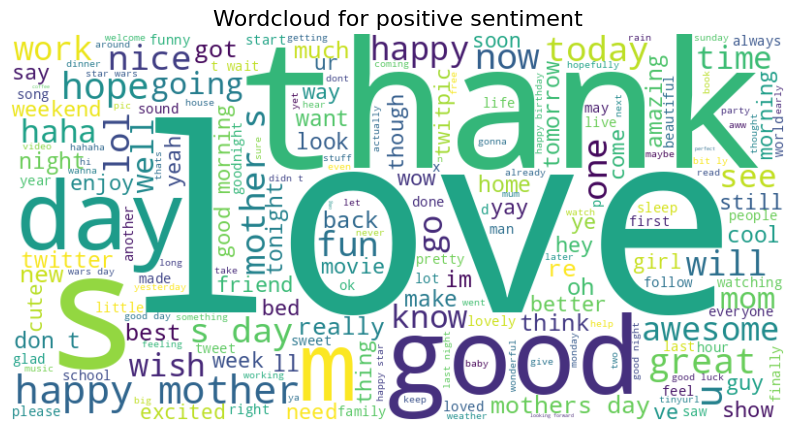

In [ ]:
# Создание облаков слов
def wordclouds(text,zag):
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'Wordcloud for {zag} sentiment', fontsize=16)
  plt.show()

wordclouds(text_n,'neutral')
wordclouds(text_neg,'negative')
wordclouds(text_p,'positive')


### 1.3 Analysis of Most Common Words for Each Target
- Analyze and visualize the most common words for each target.

 i`d have responded, if i were going http://www.dothebouncy.com/smf - some shameless plugging for the best rangers forum on earth soooo high  both of you  as much as i love to be hopeful, i reckon the chances are minimal =p i`m never gonna get my cake and stuff test test from the lg env2 hes just not that into you  oh marly, i`m so sorry!!  i hope you find her soon!! <3 <3 is cleaning the house for her family who is comming later today.. gotta restart my computer .. i thought win7 was supposed to put an end to the constant rebootiness see wat i mean bout foll0w friidays... it`s called lose f0llowers friday... smh  ahhh, i slept through the game.  i`m gonna try my best to watch tomorrow though. i hope we play army. thats it, its the end. tears for fears vs eric prydz, dj hero   http://bit.ly/2hpbg4 just in case you wonder, we are really busy today and this coming with with adding tons of new blogs and updates stay tuned  car not happy, big big dent in boot! hoping theyre not going to wr

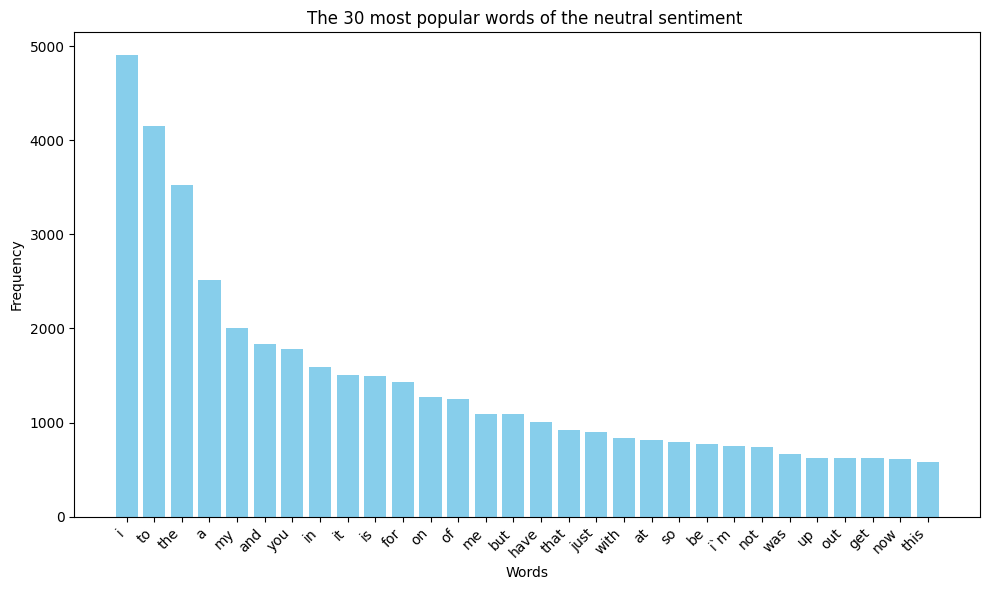

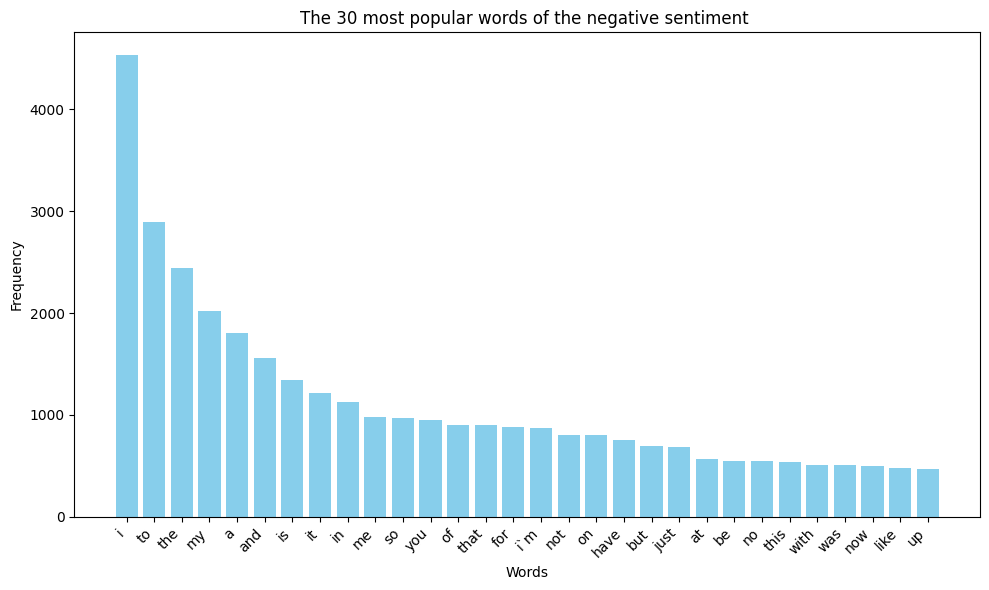

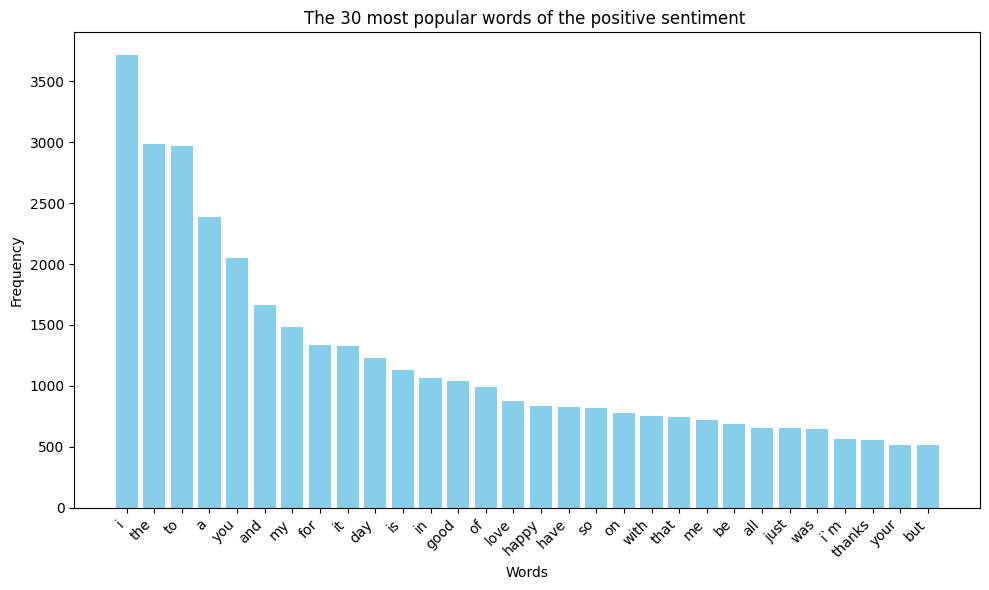

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

#чтобы удалить стоп-слова
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re


# Токенизация текста на слова, в данном случае менее удобна, чем split, т.к. он разделяет на токеты и отдельные знаки
# Но когда это происходит стоп-слова такие как you're, т.е. со знаком ' теряют смысл и уже не являются стоп-словами,
# что ухудшает работу системы, поэтому в данном случае split - оптимальное решение


print(text_n)
#удаление ссылок из текста, т.к. они не являются словами
def remove_links(text):
    # Удаление ссылок с помощью регулярного выражения
    clean_text = re.sub(r'http\S+', '', text)
    #удаление цифр и чисел, т.к. они тоже не являются словами, а нужно найти именно СЛОВА, которые чаще всего встречаются
    clean_text = re.sub(r'\d+', '', text)
    return clean_text

text_n=remove_links(text_n)
text_neg=remove_links(text_neg)
text_p=remove_links(text_p)
print(text_n)


# Удаление знаков препинания, кроме одинарной кавычки и `
def remove_punctuation(text):
    punctuation = '''!()-[]{};:"\,<>./?@#$%^&*_=+-~'''
    cleaned_text = ''
    for char in text:
        if char == "'" or char not in punctuation:
            cleaned_text += char
    return cleaned_text


# Вычищу тексты от знаков прпинания
text_n=remove_punctuation(text_n)
text_neg=remove_punctuation(text_neg)
text_p=remove_punctuation(text_p)
print(text_n)

def analysis_common_words(text,zag):

    #tokens = word_tokenize(text)
    tokens=text.split()
    #подсчёт частоты слов
    freq_dist = FreqDist(tokens)

    #30 самых частых слов
    top_words = freq_dist.most_common(30)

    #Разделение слов и их частоты для построения графика
    words, frequencies = zip(*top_words)

    plt.figure(figsize=(10, 6))
    plt.bar(words, frequencies, color='skyblue')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title(f'The 30 most popular words of the {zag} sentiment ')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

analysis_common_words(text_n,'neutral')
analysis_common_words(text_neg,'negative')
analysis_common_words(text_p,'positive')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

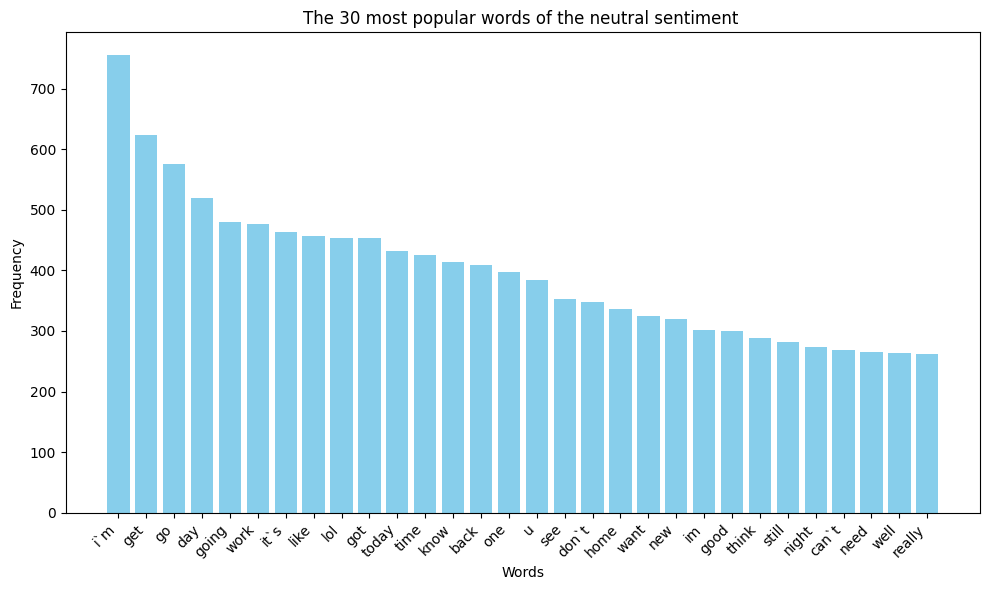

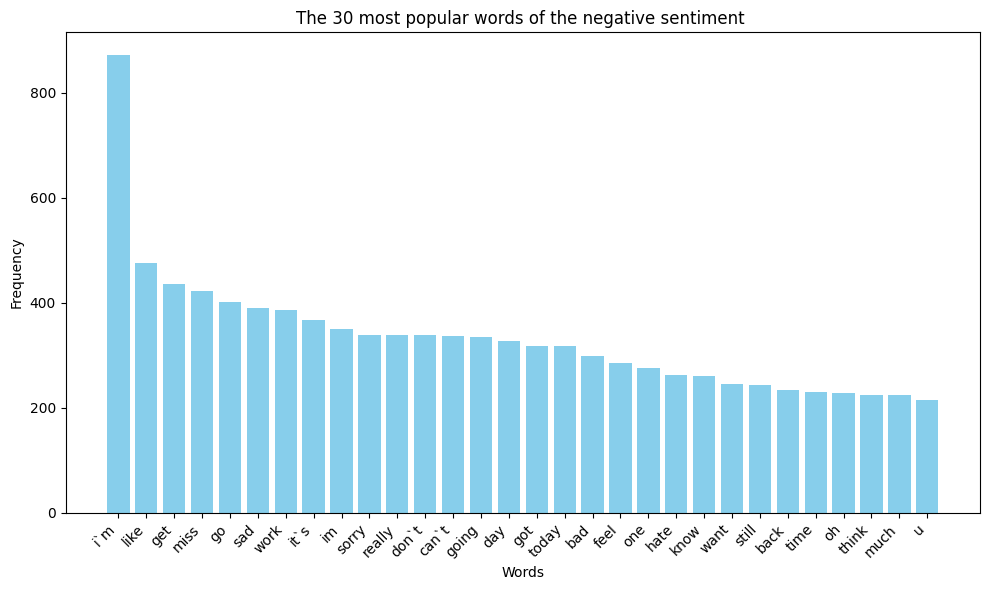

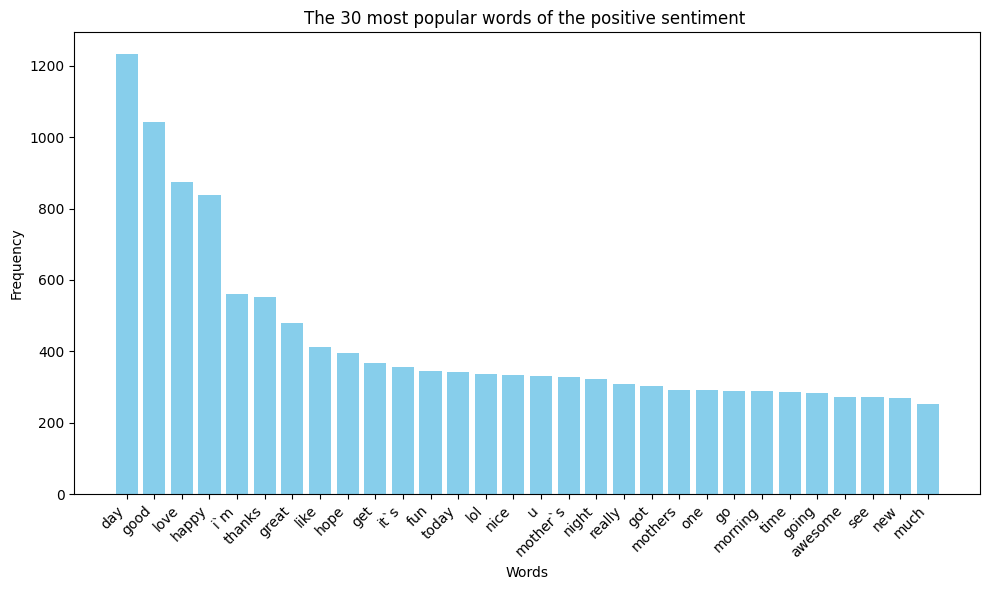

In [ ]:
import nltk
nltk.download('stopwords')


stop_words = nltk.corpus.stopwords.words('english')
print(stop_words)


def del_stop_words(text):
    #удалить ссылки из текста
    text = re.sub(r'\bhttp\w*\b', '', text)
    tokens = text.split()
    stop_words = set(stopwords.words("english"))
    # Удаление стоп-слов
    filtered_text = [word for word in tokens if word.lower() not in stop_words]
    filtered_text = ' '.join(filtered_text)
    return filtered_text


# А теперь применим функцию для вычищения стоп-слов из текста и
# выведу действительно наиболее часто встречающиеся значащие слова

text_n=del_stop_words(text_n)
text_neg=del_stop_words(text_neg)
text_p=del_stop_words(text_p)
print(text_n)

analysis_common_words(text_n,'neutral')
analysis_common_words(text_neg,'negative')
analysis_common_words(text_p,'positive')

In [ ]:
print(stop_words)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

### 1.4 Other Plots (Optional)
- Generate any additional plots that you think might provide valuable insights into the data.

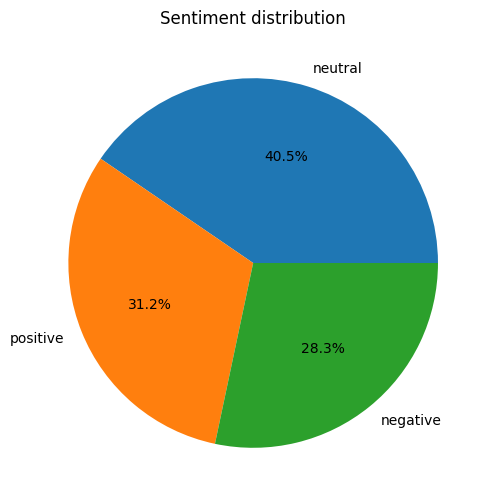

In [ ]:
plt.figure(figsize=(8, 6))
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sentiment distribution')
plt.ylabel('')
plt.show()

## Task 2: Feature Engineering

### 2.1 Text Preprocessing
- Remove punctuation, default stop words, and stop words not covered by default.

In [ ]:
"""
Punctuation, default stop words have already been removed above

"""

new_s_w=[f"{i}`d" for i in stop_words if '`' or "'" not in i]
new_s_w.extend([f"{i}'d" for i in stop_words if '`' or "'" not in i])
new_s_w.extend([f"{i}`ll" for i in stop_words if '`' or "'" not in i])
new_s_w.extend([f"{i}'ll" for i in stop_words if '`' or "'" not in i])

r= [i.replace("'", "`") for i in new_s_w if "'" in i]
new_s_w.extend(r)
new_s_w=list(set(new_s_w))


print(len(new_s_w))




pronouns = [
    'i', 'you', 'he', 'she', 'it', 'we', 'they',  # Личные местоимения
    'me', 'you', 'him', 'her', 'us', 'them',  # Возвратные местоимения
    'myself', 'yourself', 'himself', 'herself', 'itself', 'ourselves', 'yourselves', 'themselves',  # Возвратные местоимения (самостоятельные)
    'my', 'your', 'his', 'her', 'its', 'our', 'their',  # Притяжательные местоимения
    'mine', 'yours', 'his', 'hers', 'ours', 'theirs',  # Притяжательные местоимения (самостоятельные)
    'this', 'that', 'these', 'those',  # Указательные местоимения
    'who', 'whom', 'whose', 'which', 'what',  # Вопросительные местоимения
    'whoever', 'whomever', 'whichever', 'whatever',  # Вопросительные местоимения (в любом падеже)
    'some', 'any', 'few', 'several', 'many', 'much', 'more', 'most', 'none',  # Определительные местоимения
    'each', 'every', 'either', 'neither',  # Определительные местоимения (каждый, любой, ни один из двух)
    'all', 'both', 'several', 'some', 'many', 'few',  # Количественные местоимения
]
l=[i for i in pronouns if i not in new_s_w]
new_s_w.extend(l)
print(len(new_s_w))
abbreviations_pronouns = [
    "i'm", "i've", "i'll", "i'd",
    "he's", "he'd",
    "she's", "she'd",
    "it's", "it'd",
    "we're", "we've", "we'll", "we'd",
    "they're", "they've", "they'll", "they'd",
    "you're", "you've", "you'll", "you'd"
]
l=[i for i in abbreviations_pronouns if i not in new_s_w]

r= [i.replace("'", "`") for i in abbreviations_pronouns if "'" in i]

new_s_w.extend(l)
new_s_w.extend(r)

new_s_w.append('won`t')
new_s_w.append('i`m')
new_s_w.append('aren`t')
new_s_w.append('`s')
new_s_w.append('it`s')
new_s_w.append('don`t')
new_s_w.append('can`t')
new_s_w.append('couldn`t')

print(len(new_s_w))


768
834
875


In [ ]:
def del_new_stop_words(text,s_w):
    tokens = text.split()
    filtered_text = [word for word in tokens if word not in s_w]
    filtered_text = ' '.join(filtered_text)
    return filtered_text

print(len(text_n),len(text_neg),len(text_p))
text_n=del_new_stop_words(text_n,new_s_w)
text_neg=del_new_stop_words(text_neg,new_s_w)
text_p=del_new_stop_words(text_p,new_s_w)
print(len(text_n),len(text_neg),len(text_p))



467442 358623 402697
450086 343244 389410


In [ ]:


#список со всеми раличными словами которые встречаются в текстах(кроме мусора: стоп-слова, знаки преп, цифры и т.д.; который был вычищен заранее)
all_words=set(text_n.split()) & set(text_neg.split()) & set(text_p.split())

print(df)


           textID                                               text sentiment
0      cb774db0d1                I`d have responded, if I were going   neutral
1      549e992a42      Sooo SAD I will miss you here in San Diego!!!  negative
2      088c60f138                          my boss is bullying me...  negative
3      9642c003ef                     what interview! leave me alone  negative
4      358bd9e861   Sons of ****, why couldn`t they put them on t...  negative
...           ...                                                ...       ...
27476  4eac33d1c0   wish we could come see u on Denver  husband l...  negative
27477  4f4c4fc327   I`ve wondered about rake to.  The client has ...  negative
27478  f67aae2310   Yay good for both of you. Enjoy the break - y...  positive
27479  ed167662a5                         But it was worth it  ****.  positive
27480  6f7127d9d7     All this flirting going on - The ATG smiles...   neutral

[27480 rows x 3 columns]


In [ ]:
import re


# Удаляю слова, которые состоят только из 1 повторяющейся буквы
def clean_repeated_letters(text):
    # Регулярное выражение для поиска слов, состоящих из повторяющейся одной буквы
    pattern = r'\b(\w)\1{2,}\b'

    # Находим слова, состоящие из повторяющейся одной буквы, и удаляем их
    cleaned_text = re.sub(pattern, '', text)

    return cleaned_text

In [ ]:
# просмотрев датасет можно заметить, что существоет довольно большое количетво слов типа aaaahhhh,
# т.е. с повторяющимися подряд идущими буквами, однако эти слова влияют на контекст,
# поэтому их ващно оставить,преобразовав, а не просто удалять

def normalize_word(word):
    # Используем регулярное выражение, чтобы заменить повторяющиеся символы на один
    normalized = re.sub(r'(.)\1+', r'\1', word)
    return normalized


In [ ]:
# Необходимо подготовить начальный датасет: вычистить из его ориг текстов мусор: тсоп-слова, знаки преп и т.д.

a,b=df.shape
print(a)



def clean_text_itogo(text):
    # Оставляем только буквы и пробелы, удаляем все остальные символы
    cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)
    return cleaned_text

# Соберу все предложения в нужном порядке в единый список и прогоню его через очистительные функции
k=df['text'].copy().tolist()

# clean_text_itogo используется в самом конце, чтобы до
# вычиститки всех символов кроме буквенных были замечены стоп-слова,
# которые содержат какие-либо символы, помимо буквенных
for i in range(a):
  k[i]=clean_text_itogo(normalize_word(clean_repeated_letters(del_new_stop_words(del_stop_words(remove_punctuation(remove_links(k[i].lower()))),new_s_w))))
print(k)

# Датасет с очищенными текстами
new_df = df[['textID']].copy()
new_df['text']=k
new_df['sentiment']=df['sentiment']
print(new_df)


27480
['responded going', 'so sad mis san diego', 'bos bulying', 'interview leave alone', 'sons put releases already bought', 'shameles pluging best rangers forum earth', 'fedings baby fun smiles cos', 'so high', '', 'journey wow u became coler hehe posible', 'love hopeful reckon chances minimal p never gona get cake stuf', 'realy realy like song love story taylor swift', 'sharpie runing dangerously low ink', 'want go music tonight lost voice', 'test test lg env', 'uh oh sunburned', 'sok trying plot alternatives speak sigh', 'sick past days thus hair loks wierd didnt hat would lok', 'back home gona mis one', 'hes', 'oh marly sory hope find son', 'playing ghost online realy interesting new updates kirin pet metamorph third job wait dragon pet', 'cleaning house family coming later today', 'gota restart computer thought win suposed put end constant rebotines', 'se wat mean bout folw fridays caled lose flowers friday smh', 'fre filin ap ipod fun im adicted', 'sory', 'way malaysiano interne

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

file=pd.read_csv("test.csv")
r=file['text'].copy().tolist()
a,b=file.shape
print(r)
for i in range(a):
  r[i]=clean_text_itogo(normalize_word(clean_repeated_letters(del_new_stop_words(del_stop_words(remove_punctuation(remove_links(r[i].lower()))),new_s_w))))
print(r)
print(k)
columns=['text']


all_words=k+r
print(all_words)


# k_new хранит в себе информацию об 2 датасетах, чтобы в дальнейшем было одинаковое распределение признаков
k_new=pd.DataFrame(all_words, columns=columns)
print(k_new)


['Last session of the day  http://twitpic.com/67ezh', ' Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China:  (SH)  (BJ).', 'Recession hit Veronique Branquinho, she has to quit her company, such a shame!', ' happy bday!', ' http://twitpic.com/4w75p - I like it!!', ' that`s great!! weee!! visitors!', 'I THINK EVERYONE HATES ME ON HERE   lol', ' soooooo wish i could, but im in school and myspace is completely blocked', ' and within a short time of the last clue all of them', ' What did you get?  My day is alright.. haven`t done anything yet. leaving soon to my stepsister though!', 'My bike was put on hold...should have known that.... argh total bummer', ' I checked.  We didn`t win', ' .. and you`re on twitter! Did the tavern bore you that much?', 'I`m in VA for the weekend, my youngest son turns 2 tomorrow......it makes me kinda sad, he is getting so big, check out my twipics', 'Its coming out the socket  I feel like my phones hole is not a virgin. Th

### 2.2 Generate Features
- Choose one of the following methods: TF IDF, Counter, or binary feature for each word (whether you have such a word in your text).
- Generate features and update your dataset.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Создание объекта TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1500)

# Преобразование текста в матрицу TF-IDF признаков
tfidf_matrix = tfidf_vectorizer.fit_transform(k_new['text'])

# Получение списка признаков (слов)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Преобразование TF-IDF матрицы в DataFrame
import pandas as pd
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)



In [ ]:
# теперь векторизованный дс разбиваю как и было изначально -
# данные из train и test


X_for_obuch=tfidf_df[:27480]
X_for_testing=tfidf_df[27480:]
print(X_for_obuch)


       able  absolutely  abt   ac  aces  acount  acros  action  actualy   ad  \
0       0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
1       0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
2       0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
3       0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
4       0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
...     ...         ...  ...  ...   ...     ...    ...     ...      ...  ...   
27475   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
27476   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
27477   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
27478   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
27479   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   

       ...  yet   yo  you  young  youre

## Task 3: Model Fitting

In [ ]:

# Разделение данных на обучающий и тестовый наборы

y = new_df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X_for_obuch, y, test_size=0.2, random_state=42)

print(X_train)

       able  absolutely  abt   ac  aces  acount  acros  action  actualy   ad  \
21208   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
18264   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
9683    0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
9688    0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
22727   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
...     ...         ...  ...  ...   ...     ...    ...     ...      ...  ...   
21575   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
5390    0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
860     0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
15795   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   
23654   0.0         0.0  0.0  0.0   0.0     0.0    0.0     0.0      0.0  0.0   

       ...  yet   yo  you  young  youre

### 3.1 Fitting NaiveBayes
- Fit a Naive Bayes model to the data.

In [ ]:


# Инициализация и обучение модели на данных
# использую MultinomialNB, а не GaussianNB, т.к. он применяется, когда работаем со счётчиками с текстами
model =MultinomialNB()
model.fit(X_train, y_train)

# Предсказание на тестовом наборе данных
y_pred = model.predict(X_test)

# Оценка точности модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")




Accuracy: 0.6431950509461426


### 3.2 Fitting SVC
- Fit a Support Vector Classifier (SVC) to the data.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Создание и обучение SVC

"""
В другом блокноте проводила грид сёрч(парал работало их несколько, но на момент отправки уже нет 7ч на гридсёрч здесь)
и коэф ниже наилучшие, вот из чего был грид сёрч:
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}

"""


svc = SVC(C=10, gamma='scale', kernel='rbf',class_weight='balanced')
svc.fit(X_train, y_train)

# Предсказание на тестовом наборе данных
y_pred = svc.predict(X_test)



# Оценка точности модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.6806768558951966


##Предсказание итоговое


In [ ]:
"""
Ниже я проанализирую модели)
"""



file_path = 'test.csv'
data = pd.read_csv(file_path)


res = data[['textID']].copy()
y_result = svc.predict(X_for_testing)
columns=['sentiment']




y_res=pd.DataFrame(y_result, columns=columns)
res['sentiment']=y_res
res.to_csv('solution.csv', index=False)
print(res)

          textID sentiment
0     f87dea47db   neutral
1     96d74cb729  positive
2     eee518ae67  negative
3     01082688c6  positive
4     33987a8ee5   neutral
...          ...       ...
3529  e5f0e6ef4b  negative
3530  416863ce47  negative
3531  6332da480c   neutral
3532  df1baec676  positive
3533  469e15c5a8  positive

[3534 rows x 2 columns]


### 3.3 Fitting Decision Tree
- Fit a Decision Tree model to the data.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Создание и обучение модели дерева решений
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Предсказание на тестовом наборе данных
y_pred = tree_model.predict(X_test)

# Оценка точности модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.6453784570596798


### 3.4 Model Comparison and Hyperparameter Tuning
- Compare the performance of the three models.
- Perform cross-validation and grid search to find the best hyperparameters for each model.

In [ ]:
#1 NaiveBayes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"Naive Bayes Cross-Validation Mean Accuracy: {nb_scores.mean()}")

# Поиск по сетке гиперпараметров для Naive Bayes
param_grid = {}  # Параметры для поиска по сетке (в данном случае - пусто, так как Naive Bayes не имеет гиперпараметров)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Получение наилучших гиперпараметров
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Оценка наилучшей модели на тестовом наборе данных
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Bayes Test Accuracy: {accuracy}")




Naive Bayes Cross-Validation Mean Accuracy: 0.6476529513981222
Best hyperparameters: {}
Naive Bayes Test Accuracy: 0.6431950509461426


In [ ]:
#SVC

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

param_grid = {'C': [0.1, 1, 11], 'gamma': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}


# Создаем модель SVC
svc = SVC()


# Поиск по сетке гиперпараметров+cross-validation(разбила данные на 3 части(складки))
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=3)
grid_search.fit(X_train, y_train)

# Получение наилучших гиперпараметров
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Оценка наилучшей модели на тестовом наборе данных
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVC Test Accuracy: {accuracy}")



"""

Поставила работать несколько блокнот параллельно. Вывод того блокнота:

SVC Cross-Validation Mean Accuracy: 0.6848614314955002
Best hyperparameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
SVC Test Accuracy: 0.7021470160116449
"""


In [ ]:
#Decision Tree
from sklearn.model_selection import GridSearchCV, cross_val_score
# Поиск по сетке гиперпараметров для Decision Tree
param_grid = {'max_depth': [3, 5, 7, None]}  # Гиперпараметры для поиска по сетке
grid_search = GridSearchCV(estimator=tree_model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Получение наилучших гиперпараметров
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Оценка наилучшей модели на тестовом наборе данных
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Test Accuracy: {accuracy}")


'''
Этот же код, но из другого блокнота, который поставила работать параллельно:

Best hyperparameters: {'max_depth': None}
Decision Tree Test Accuracy: 0.6444687045123726
'''



KeyboardInterrupt: ignored

## Task 4: Kaggle Submission

### Submit your predictions to Kaggle and compete with other students!
Don't forget to leave a link to your Kaggle profile so that we can identify your work.
<br>
GL & HF 😉

In [ ]:
# https://www.kaggle.com/helenpalto
# name in Kaggle: Helen_Palto
#https://www.kaggle.com/competitions/epic-classification1-1/leaderboard - ссылка на соревнование